In [12]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames
using CSV

In [13]:
using Revise
using Newtrinos
using Newtrinos.osc

In [14]:

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   dayabay= Newtrinos.dayabay.configure(physics),
   gerda=Newtrinos.gerda.configure(physics)
);

par= Newtrinos.get_params(experiments)

[ Info: Loading dayabay data
[ Info: Loading Gerda data


(N = 100.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [15]:

all_priors = Newtrinos.get_priors(experiments)


vars_to_scan = ( r=31,  N=31)  

modified_priors = (
    N = all_priors.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)

(N = Uniform{Float64}(a=2.0, b=50.0), m₀ = Uniform{Float64}(a=1.0e-6, b=1.0), r = Uniform{Float64}(a=1.0e-8, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = 0.8556288707523761)

In [16]:
likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)

Progress: 100%|█████████████████████████████████████████| Time: 0:14:30


NewtrinosResult((r = [1.0e-8, 0.033333343, 0.066666676, 0.100000009, 0.133333342, 0.166666675, 0.200000008, 0.233333341, 0.266666674, 0.30000000699999996  …  0.700000003, 0.733333336, 0.766666669, 0.8000000020000001, 0.8333333350000001, 0.866666668, 0.900000001, 0.9333333340000001, 0.966666667, 1.0], N = [2.0, 3.6, 5.2, 6.800000000000001, 8.4, 10.0, 11.600000000000001, 13.2, 14.8, 16.4  …  35.599999999999994, 37.199999999999996, 38.800000000000004, 40.400000000000006, 42.0, 43.6, 45.2, 46.8, 48.4, 50.0]), (m₀ = [0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01; … ; 0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; … ; 0.0024752999999999997 0.002475299999

In [17]:
display(minimum(result_NN.values.llh))

-29004.783472882988

In [18]:
#JLD2.@save "/home/sofialon/Newtrinos.jl/scan_final/gerda_dayabay_NNM_NO m0=0.001.jld2" result_NN

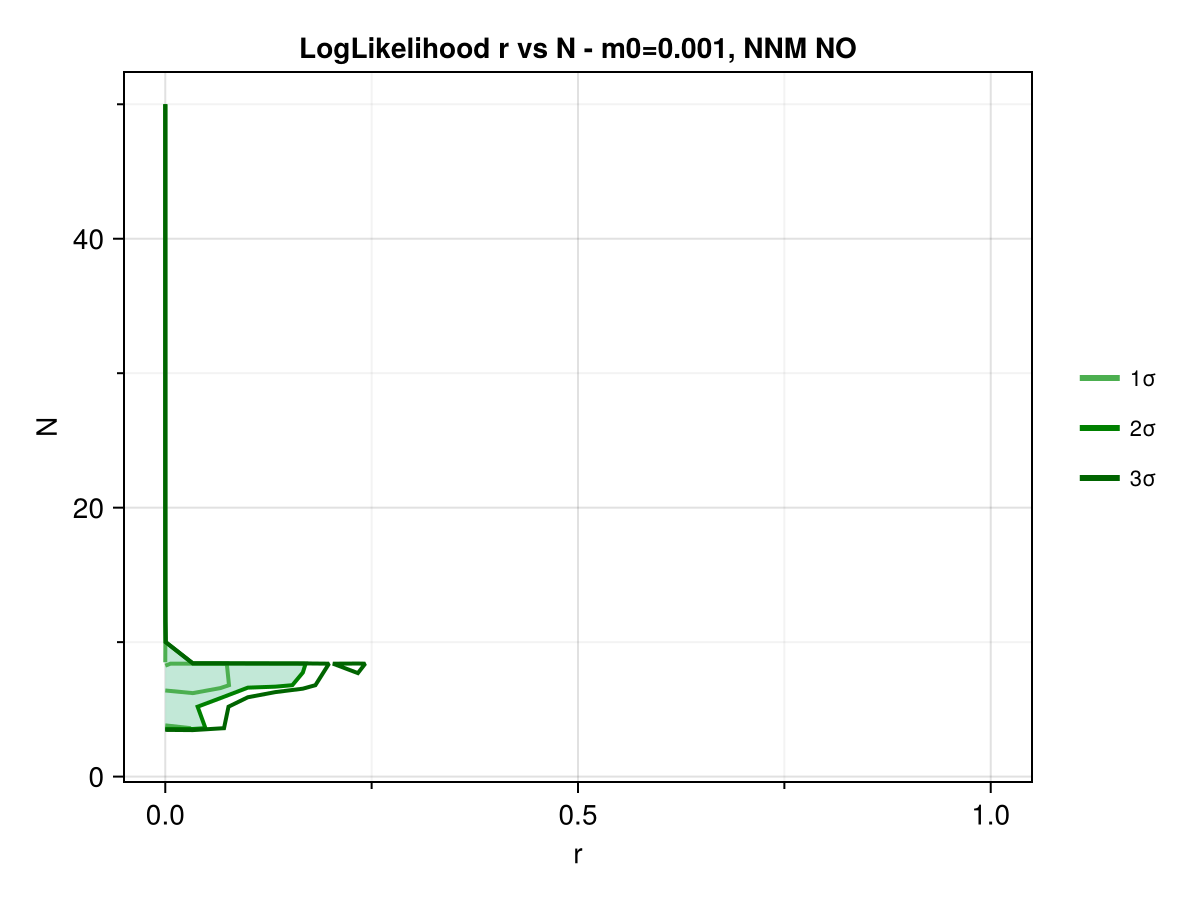

In [19]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="LogLikelihood r vs N - m0=0.001, NNM NO")
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/aug_plots/gerda/legend1000_rm0_N100_NNM_NO.png", img)